Loading weights: 100%|██████████| 101/101 [00:00<00:00, 52539.34it/s]
[transformers] RobertaModel LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.bias      | UNEXPECTED | 
pooler.dense.weight        | MISSING    | 
pooler.dense.bias          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Extracting embeddings... this may take a few minutes.
Running t-SNE...


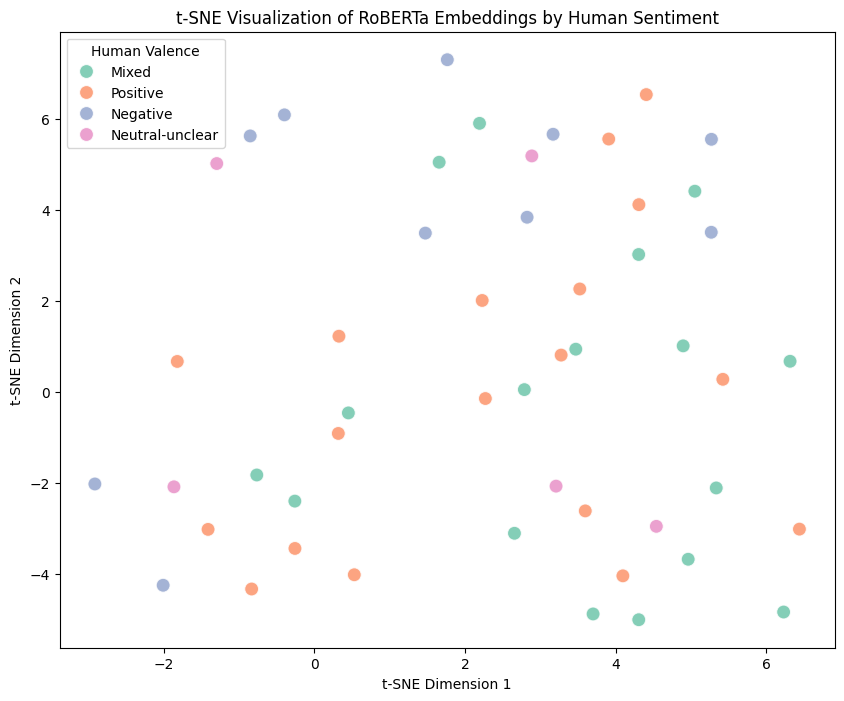

In [ ]:
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
#
# 1. Load your human annotations
df = pd.read_csv('human_annotation.csv')

# Drop rows with missing lyrics or labels using the correct column name
df = df.dropna(subset=['raw_lyrics', 'primary_valence'])

# 2. Initialize Model and Tokenizer
model_name = "j-hartmann/emotion-english-distilroberta-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# 3. Function to extract embeddings
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    return embedding

# 4. Apply to dataset
print("Extracting embeddings... this may take a few minutes.")
df['embedding'] = df['raw_lyrics'].apply(get_embedding)

# 5. Dimensionality Reduction using t-SNE
print("Running t-SNE...")
import numpy as np
X = np.stack(df['embedding'].values)

tsne = TSNE(n_components=2, random_state=42, perplexity=15)
X_tsne = tsne.fit_transform(X)

df['tsne_1'] = X_tsne[:, 0]
df['tsne_2'] = X_tsne[:, 1]

# 6. Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='primary_valence', # Updated to match your CSV
    palette='Set2',
    data=df,
    s=100,
    alpha=0.8
)
plt.title('t-SNE Visualization of RoBERTa Embeddings by Human Sentiment')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(title='Human Valence')
plt.show()